In [ ]:
#0-1 EDAセッティング　基本設定

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

%matplotlib inline
%config Inlinebackend.figure_format='retina'
sns.set(style='whitegrid')
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns',100)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#0-2 パーケ読込
train=pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/Kaggle/IEEE-CIS Fraud Detection/加工後/train_feature.parquet')
test =pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/Kaggle/IEEE-CIS Fraud Detection/加工後/test_feature.parquet')

print(f"Memory Usage: {train.memory_usage().sum() / 1024**2:.2f} MB")
train.head()

Memory Usage: 457.97 MB


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,...,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_26,id_30,id_31,id_33,id_34,id_36,id_37,id_38,DeviceType,DeviceInfo,Amt50,Amt99,Amt9,Amt_decimal,Amt_turning,Amt_range,D8bin,High_Fraud_None,High_Fraud_other,Res_Area,Res_Area_log,resolution_log,time_24h,time_24h_sin,time_24h_cos,time_week,time_week_sin,time_week_cos,time_day,time_month
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,1,1,1,NaN,0,0,NaN,NaN,NaN,0.000000,0.000000,1.000000,0,0.0,1.0,0.000000,0
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,M0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,0,1,0,NaN,0,0,NaN,NaN,NaN,0.000278,0.000073,1.000000,0,0.0,1.0,0.000012,0
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,debit,330.0,87.0,287.0,NaN,outlook.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,315.0,NaN,NaN,NaN,315.0,T,T,T,M0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,0,1,1,NaN,0,0,NaN,NaN,NaN,0.019167,0.005018,0.999987,0,0.0,1.0,0.000799,0
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,debit,476.0,87.0,NaN,NaN,yahoo.com,NaN,2.0,5.0,0.0,0.0,0.0,4.0,0.0,0.0,1.0,0.0,1.0,0.0,25.0,1.0,112.0,112.0,0.0,94.0,0.0,NaN,NaN,NaN,NaN,84.0,NaN,NaN,NaN,NaN,111.0,NaN,NaN,NaN,M0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0,0,1,1,NaN,0,0,NaN,NaN,NaN,0.027500,0.007199,0.999974,0,0.0,1.0,0.001146,0
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,credit,420.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,NaN,-480.0,New,NotFound,166.0,NaN,542.0,144.0,NaN,NaN,Android 7.0,samsung browser 6.2,2220x1080,match_status:2,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M,1,0,0,0,1,1,NaN,0,0,2397600.0,14.689979,14.689979,0.029444,0.007708,0.999970,0,0.0,1.0,0.001227,0


In [ ]:
#0-3 下処理前EDA　カラム説明　Kaggle引用

'''
【アイデンティティテーブル】
このテーブル内の変数は、取引に関連付けられた識別情報（ネットワーク接続情報
（IP、ISP、プロキシなど）とデジタル署名（UA/ブラウザ/OS/バージョンなど））
です。
これらは、Vestaの不正防止システムとデジタルセキュリティパートナーによって収
集されます。
（フィールド名はマスクされており、プライバシー保護と契約締結のため、ペアワイ
ズ辞書は提供されません。）

カテゴリ別特徴: DeviceType DeviceInfo id_12 - id_38

【取引表】
TransactionDT: 指定された参照日時からのタイムデルタ（実際のタイムスタンプで
　　　　　　　 はありません）
TransactionAMT: 取引支払金額（米ドル）
ProductCD: 製品コード、各トランザクションの製品
card1 - card6: カードの種類、カードのカテゴリ、発行銀行、国などの支払いカー
               ド情報。
addr: 住所
dist: 距離
P_ および (R__) emaildomain: 購入者と受信者のメールドメイン
C1-C14: 支払いカードに関連付けられているアドレスがいくつ見つかったかなどのカ
　　　　ウント。実際の意味はマスクされています。
D1-D15: 前回の取引間の日数などの時間差分。
M1-M9: カード名や住所などが一致します。
Vxxx: Vesta は、ランキング、カウント、その他のエンティティ関係を含む豊富な機
　　　能を設計しました。
カテゴリカル特徴: ProductCD card1 - card6 addr1, addr2 P_emaildomain
                  R_emaildomain M1 - M9

'''

'\n【アイデンティティテーブル】\nこのテーブル内の変数は、取引に関連付けられた識別情報（ネットワーク接続情報\n（IP、ISP、プロキシなど）とデジタル署名（UA/ブラウザ/OS/バージョンなど））\nです。\nこれらは、Vestaの不正防止システムとデジタルセキュリティパートナーによって収\n集されます。\n（フィールド名はマスクされており、プライバシー保護と契約締結のため、ペアワイ\nズ辞書は提供されません。）\n\nカテゴリ別特徴: DeviceType DeviceInfo id_12 - id_38\n\n【取引表】\nTransactionDT: 指定された参照日時からのタイムデルタ（実際のタイムスタンプで\n\u3000\u3000\u3000\u3000\u3000\u3000\u3000 はありません）\nTransactionAMT: 取引支払金額（米ドル）\nProductCD: 製品コード、各トランザクションの製品\ncard1 - card6: カードの種類、カードのカテゴリ、発行銀行、国などの支払いカー\n               ド情報。\naddr: 住所\ndist: 距離\nP_ および (R__) emaildomain: 購入者と受信者のメールドメイン\nC1-C14: 支払いカードに関連付けられているアドレスがいくつ見つかったかなどのカ\n\u3000\u3000\u3000\u3000ウント。実際の意味はマスクされています。\nD1-D15: 前回の取引間の日数などの時間差分。\nM1-M9: カード名や住所などが一致します。\nVxxx: Vesta は、ランキング、カウント、その他のエンティティ関係を含む豊富な機\n\u3000\u3000\u3000能を設計しました。\nカテゴリカル特徴: ProductCD card1 - card6 addr1, addr2 P_emaildomain\n                  R_emaildomain M1 - M9\n\n'

In [ ]:

'''
後続処理
済①下処理前EDA
　　なお、長くなったため、見出しに特徴量等を変化させたものは(活用)、
　　変化はないが有効な情報に(参考)を付与した。
済②欠損処理の検討
　以下の２点により省略。
　LightGBMでは欠損値について、欠損値として学習できること。
　現時点である程度の精度は確保できており、欠損値補完により精度が落ちるリスクがあること。

済③特徴量変換(ビン分け、外れ値処理、ラベル化の検討)
　主にストリング型、オブジェクト型について検討を行う。
  int,froat型については相関関係は前回確認済みであり、LightGBMでは
  外れ値に強く、不均衡モデルのためばらつき自体が情報となることを
  念頭にいれて確認。

④下処理後EDA
　③実施後にモデル評価したのちに重要度が高いものがあれば実施。
　なお、完了後は不要カラムの削除及び、データサイズの軽量化を忘れずに実施すること。

⑤モデル分析・評価
　セグメント別(Amt_turning別),lightGBM(重み付け(高金額帯のみ)、スケールウェイト、TSCV)

'''

'\n後続処理\n済①下処理前EDA\n\u3000\u3000なお、長くなったため、見出しに特徴量等を変化させたものは(活用)、\n\u3000\u3000変化はないが有効な情報に(参考)を付与した。\n済②欠損処理の検討\n\u3000以下の２点により省略。\n\u3000LightGBMでは欠損値について、欠損値として学習できること。\n\u3000現時点である程度の精度は確保できており、欠損値補完により精度が落ちるリスクがあること。\n\n済③特徴量変換(ビン分け、外れ値処理、ラベル化の検討)\n\u3000主にストリング型、オブジェクト型について検討を行う。\n  int,froat型については相関関係は前回確認済みであり、LightGBMでは\n  外れ値に強く、不均衡モデルのためばらつき自体が情報となることを\n  念頭にいれて確認。\n\n④下処理後EDA\n\u3000③実施後にモデル評価したのちに重要度が高いものがあれば実施。\n\u3000なお、完了後は不要カラムの削除及び、データサイズの軽量化を忘れずに実施すること。\n\n⑤モデル分析・評価\n\u3000セグメント別(Amt_turning別),lightGBM(重み付け(高金額帯のみ)、スケールウェイト、TSCV)\n\n'

In [ ]:
#1-1　モデル試走

import lightgbm as lgb

title = "IEEE-CIS 不正検知モデル試走"
train_df = train
target_cols_to_drop=['isFraud', 'TransactionID']
X = train_df.drop(target_cols_to_drop, axis=1)
y = train_df['isFraud']

# 1. モデル定義
ratio = len(y[y==0]) / len(y[y==1])
model = lgb.LGBMClassifier(
n_estimators=300,
random_state=42,
importance_type='gain',
scale_pos_weight=ratio,
n_jobs=-1
)

# 2. 学習実行
print(f" {title} 開始... ({X.shape[1]} カラム)")
model.fit(X, y)
print("✅ 学習完了。")

# 重要度の算出
importance_df = pd.DataFrame({
        'feature': X.columns,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False).reset_index(drop=True)

 IEEE-CIS 不正検知モデル試走 開始... (344 カラム)
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 20663, number of negative: 569877
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 1.672500 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 37597
[LightGBM] [Info] Number of data points in the train set: 590540, number of used features: 344
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034990 -> initscore=-3.317076
[LightGBM] [Info] Start training from score -3.317076
✅ 学習完了。


In [ ]:
##1-1　モデル試走　テストデータ適用

# --- テストデータに対する予測と提出ファイルの作成 ---

print("テストデータの予測を開始します...")

# 1. テストデータから、学習時と同じ特徴量（X.columns）を抽出
# ※ testデータフレームが既に読み込まれており、特徴量エンジニアリング済みであることが前提です
X_test = test[X.columns]

# 2. 確率（prob）を予測（不正である確率を取り出すため [:, 1] を指定）
test_preds = model.predict_proba(X_test)[:, 1]

# 3. 提出用データフレームの作成
# 提出フォーマットに合わせて、TransactionID と予測した確率（isFraud）をセット
submission = pd.DataFrame({
    'TransactionID': test['TransactionID'],
    'isFraud': test_preds
})

# 4. CSVファイルとして出力
file_name = 'submission_single_model.csv'
submission.to_csv(file_name, index=False)

print(f"完了！ '{file_name}' を作成しました。")
print(submission.head())

テストデータの予測を開始します...
完了！ 'submission_single_model.csv' を作成しました。
   TransactionID   isFraud
0        3663549  0.046752
1        3663550  0.051911
2        3663551  0.022435
3        3663552  0.015812
4        3663553  0.114780


private score 0.884
Public Score  0.921

In [ ]:
#1-1　モデル試走　評価
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import lightgbm as lgb

def report_model_performance(model, X, y, original_df, custom_list=None, title="モデル評価レポート"):
    """
    モデルの基本指標、荷重リコール、混同行列、特徴量重要度を一括表示する関数
    """
    # 1. 予測値の取得
    y_prob = model.predict_proba(X)[:, 1]
    y_pred = model.predict(X)

    # 2. 基本指標の算出
    roc_auc = roc_auc_score(y, y_prob)
    report = classification_report(y, y_pred)
    cm = confusion_matrix(y, y_pred)

    # 3. 荷重リコール (Weighted Recall) の算出
    safe_amt = original_df['TransactionAmt'].astype('float64').fillna(0)
    df_eval = pd.DataFrame({'isFraud': y.values, 'predicted': y_pred, 'amt': safe_amt.values})

    fraud_actual = df_eval[df_eval['isFraud'] == 1]
    total_fraud_amt = fraud_actual['amt'].sum()
    correct_fraud_amt = fraud_actual[fraud_actual['predicted'] == 1]['amt'].sum()
    weighted_recall = correct_fraud_amt / total_fraud_amt if total_fraud_amt > 0 else 0

    # --- 結果の表示 ---
    print(f"\n{'='*10} {title} {'='*10}")
    print(f" ROC-AUC: {roc_auc:.4f}")
    print(f" 荷重リコール (Weighted Recall): {weighted_recall:.4f}")

    print(f"\n--- 詳細レポート ---")
    print(report)

    print(f"\n--- 混同行列 ---")
    print(f"実際＼予測 | 0(正常) | 1(不正)")
    print(f"0(正常)    | {cm[0][0]:7d} | {cm[0][1]:7d}")
    print(f"1(不正)    | {cm[1][0]:7d} | {cm[1][1]:7d}")

    # 4. 特徴量重要度の確認
    importance_df = pd.DataFrame({
        'feature': X.columns,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False).reset_index(drop=True)

    if custom_list:
        # 指定されたリストのうち、実際に存在するカラムだけを抽出
        existing_custom = [c for c in custom_list if c in X.columns]
        if existing_custom:
            print(f"\n--- 指定特徴量の戦績 (全{len(X.columns)}カラム中) ---")
            res = importance_df[importance_df['feature'].isin(existing_custom)].copy()
            res['rank'] = res.index + 1
            print(res[['rank', 'feature', 'importance']])

    # 5. 寄与度 0 の確認
    zero_cols = importance_df[importance_df['importance'] == 0]['feature'].tolist()
    print(f"\n 寄与度 0 のカラム数: {len(zero_cols)} / {len(X.columns)}")

    return importance_df, df_eval

# --- ここから実行コマンド ---

# 1. 注目したい自作特徴量のリストを定義
my_features = [
    'Amt50', 'Amt99', 'Amt9', 'Amt_decimal', 'Amt_range',
    'Amt_turning', 'V257bin', 'D8bin',
    'High_Fraud_None', 'High_Fraud_other'
    'resolution_log','time_24h',
    'time_week', 'time_day', 'time_month'
    'Res_Area_log','Res_Area'
]

# 2. 関数の実行
# 直前の学習セルで作成された model, X, y を使用します
importance_df, eval_df = report_model_performance(
    model=model,
    X=X,
    y=y,
    original_df=train,
    custom_list=my_features,
    title="モデル評価レポート"
)


========== モデル評価レポート ==========
 ROC-AUC: 0.9778
 荷重リコール (Weighted Recall): 0.8947

--- 詳細レポート ---
              precision    recall  f1-score   support

           0       1.00      0.93      0.96    569877
           1       0.33      0.90      0.48     20663

    accuracy                           0.93    590540
   macro avg       0.66      0.92      0.72    590540
weighted avg       0.97      0.93      0.95    590540


--- 混同行列 ---
実際＼予測 | 0(正常) | 1(不正)
0(正常)    |  531546 |   38331
1(不正)    |    2051 |   18612

--- 指定特徴量の戦績 (全344カラム中) ---
     rank          feature    importance
64     65         time_24h  13019.620861
68     69      Amt_turning  11612.999802
69     70      Amt_decimal  11053.776764
110   111        time_week   3998.597321
166   167         time_day   1396.822002
173   174        Amt_range   1279.965111
229   230            Amt50    670.323006
233   234            Amt99    606.995300
236   237             Amt9    589.559395
245   246  High_Fraud_None    500.035995

In [ ]:
# 1-4 モデル試走　不要カラム削除

def prune_low_importance_features(df, importance_df, threshold=0):
    """
    重要度が threshold 以下のカラムを削除する関数
    """
    # 重要度がしきい値を超えるカラム名を取得
    keep_features = importance_df[importance_df['importance'] > threshold]['feature'].tolist()

    # 元々のdfにあるカラムのうち、残すべきもの + (isFraud, time_month, Amt_turning 等の必須列) を特定
    essential_cols = ['isFraud', 'TransactionID', 'TransactionDT', 'time_day', 'time_month', 'Amt_turning']
    cols_to_keep = list(set(keep_features) | set(essential_cols))

    # 存在するカラムだけを抽出（エラー回避）
    cols_to_keep = [c for c in cols_to_keep if c in df.columns]

    return df[cols_to_keep]

print("✅ 関数 'prune_low_importance_features' を定義しました。")

#＃＃＃＃＃＃＃＃＃＃＃＃＃＃＃＃＃＃＃＃＃＃＃＃＃＃＃＃＃＃＃＃＃＃＃＃＃＃＃＃＃＃＃＃＃

# --- 1. カラム削除の実行 ---
# 元の列数を記録
original_cols = train.shape[1]

# 重要度0のものを削る（importance_df がある前提です）
train = prune_low_importance_features(train, importance_df, threshold=0)

# 2. TestデータもTrainと同じカラム構成に合わせる（これ重要！）
# Trainにあるカラムだけを抽出（ターゲットの isFraud 以外）
keep_cols_test = [c for c in train.columns if c != 'isFraud']
test = test[keep_cols_test]

# --- 3. 結果の表示 ---
print(f"🧹 削除完了！")
print(f"📉 カラム数: {original_cols} -> {train.shape[1]}")
print(f"✅ Testデータの整合性: {'一致' if set(test.columns) == set(train.drop(columns='isFraud').columns) else '不一致あり'}")

# 念のため現在の time_month 構成を最終確認
print("\n📅 現在のTrain月構成:")
print(train['time_month'].value_counts().sort_index())


✅ 関数 'prune_low_importance_features' を定義しました。
🧹 削除完了！
📉 カラム数: 346 -> 317
✅ Testデータの整合性: 一致

📅 現在のTrain月構成:
time_month
0    134339
1     89399
2     92189
3     98615
4     83571
5     92427
Name: count, dtype: int64


In [ ]:
# 1-5　モデル試走　ダウンキャスト

def reduce_mem_usage_safe(df, verbose=True):
    start_mem = df.memory_usage().sum() / 1024**2
    for col in df.columns:
        col_type = df[col].dtype

        if col_type != object and col_type.name != 'category':
            c_min = df[col].min()
            c_max = df[col].max()

            # --- ここにガードを入れる ---
            # 整数型の場合
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    target_type = np.int8
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    target_type = np.int16
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    target_type = np.int32
                else:
                    target_type = np.int64
            # 浮動小数点型の場合
            else:
                target_type = np.float32 # 精度維持のため32を基本にする

            # 【重要】今の型よりもメモリを食う（アイテムあたりのバイト数が増える）なら、何もしない
            if np.dtype(target_type).itemsize < np.dtype(col_type).itemsize:
                df[col] = df[col].astype(target_type)

    end_mem = df.memory_usage().sum() / 1024**2
    if verbose:
        print(f'📉 真のメモリ推移: {start_mem:.2f} MB -> {end_mem:.2f} MB')
    return df

# 再チャレンジ！
train = reduce_mem_usage_safe(train)
test = reduce_mem_usage_safe(test)

📉 真のメモリ推移: 415.17 MB -> 393.77 MB
📉 真のメモリ推移: 361.55 MB -> 343.19 MB


In [ ]:
# 2-1　モデル実装準備　TSCVの確認(月別不正件数、割合)

import numpy as np

# 1. 30日を「1ヶ月」として作成し、最大値を5に固定（6以降を5にまとめる）
train['time_month'] = (train['TransactionDT'] // (86400 * 30)).astype(int)
train['time_month'] = train['time_month'].clip(upper=5)

# 2. time_month と Amt_turning でグループ化して集計
monthly_turning_stats = train.groupby(['time_month', 'Amt_turning'])['isFraud'].agg(['count', 'sum', 'mean']).reset_index()

# 3. カラム名のリネームと不正率のパーセント変換
monthly_turning_stats.columns = ['Month', 'Amt_Bin', 'Total', 'Fraud', 'Rate(%)']
monthly_turning_stats['Rate(%)'] = (monthly_turning_stats['Rate(%)'] * 100).round(2)

# 4. 結果の表示
print("========== 【修正版】月別 × Amt_turning 統計 ==========")
print(monthly_turning_stats.sort_values(['Month', 'Amt_Bin']).to_string(index=False))

========== 【修正版】月別 × Amt_turning 統計 ==========
 Month  Amt_Bin  Total  Fraud  Rate(%)
     0        0   6437    280     4.35
     0        1  56176   1208     2.15
     0        2  63039   1601     2.54
     0        3   5316    154     2.90
     1        0   4469    373     8.35
     1        1  42329   1412     3.34
     1        2  38757   1650     4.26
     1        3   4283    192     4.48
     2        0   4848    478     9.86
     2        1  42151   1295     3.07
     2        2  40307   1743     4.32
     2        3   4462    184     4.12
     3        0   4827    421     8.72
     3        1  43623   1462     3.35
     3        2  44859   1630     3.63
     3        3   4718    336     7.12
     4        0   4373    278     6.36
     4        1  38618   1068     2.77
     4        2  38494   1365     3.55
     4        3   3818    251     6.57
     5        0   4910    468     9.53
     5        1  42516   1225     2.88
     5        2  42803   1347     3.15
     5        3  

0月目の３ビンの不正件数がやや少ないが、予定通りTSCV及びセグメント別のモデル学習で実施を行う。また、初月の不正割合は他の月と比して低かったため、2カ月スライトのTSCVで検証を行う。

In [ ]:
# 3-1　モデル実装　セグメント別TSCV　ビン0(20＄以下)

from sklearn.metrics import (roc_auc_score, average_precision_score,
                             precision_score,recall_score, f1_score)


# --- 設定 ---
threshold = 0.2
train_b0 = train[train['Amt_turning'] == 0].copy()
features = [c for c in train.columns if c not in ['isFraud', 'TransactionID']]
test_months = [2, 3, 4, 5]

metrics_store = []

print(f"直近2ヶ月スライド型 検証開始（Threshold: {threshold}）...")

for val_m in test_months:
    # 直近2ヶ月（val_m-2 と val_m-1）を学習データとして抽出
    train_mask = (train_b0['time_month'] >= (val_m - 2)) & (train_b0['time_month'] < val_m)

    X_train = train_b0[train_mask][features]
    y_train = train_b0[train_mask]['isFraud']

    val_data = train_b0[train_b0['time_month'] == val_m]
    X_val = val_data[features]
    y_val = val_data['isFraud']
    amounts = val_data['TransactionAmt']

    if len(X_train) == 0 or len(X_val) == 0:
        continue

    ratio = (y_train == 0).sum() / (y_train == 1).sum()

    model = lgb.LGBMClassifier(n_estimators=300,
                               learning_rate=0.05,
                               scale_pos_weight=ratio,
                               random_state=42,
                               verbose=-1)

    model.fit(X_train, y_train, eval_metric='average_precision')

    probs = model.predict_proba(X_val)[:, 1]
    preds = (probs >= threshold).astype(int)

    # 指標計算
    auc_roc = roc_auc_score(y_val, probs)
    auc_pr = average_precision_score(y_val, probs)
    det_mask = (preds == 1) & (y_val == 1)
    mis_mask = (preds == 0) & (y_val == 1)

    metrics_store.append({
        'auc_roc': auc_roc, 'auc_pr': auc_pr,
        'weighted_recall': amounts[det_mask].sum() / amounts[y_val == 1].sum() if (y_val == 1).any() else 0,
        'avg_det_amt': amounts[det_mask].mean() if det_mask.any() else 0,
        'avg_mis_amt': amounts[mis_mask].mean() if mis_mask.any() else 0,
        'p1': precision_score(y_val, preds, pos_label=1, zero_division=0),
        'r1': recall_score(y_val, preds, pos_label=1, zero_division=0),
        'f1_1': f1_score(y_val, preds, pos_label=1, zero_division=0),
        'p0': precision_score(y_val, preds, pos_label=0),
        'r0': recall_score(y_val, preds, pos_label=0),
        'f1_0': f1_score(y_val, preds, pos_label=0)
    })

# --- 平均値の算出 ---
avg = pd.DataFrame(metrics_store).mean()

print("\n" + "="*75)
print(f" 直近2ヶ月スライド平均レポート (Threshold: {threshold})")
print("="*75)
print(f"平均検知額: ${avg.avg_det_amt:,.0f} | 平均見逃し額: ${avg.avg_mis_amt:,.0f}")
print(f"金額荷重Recall: {avg.weighted_recall:.4f} | PR-AUC: {avg.auc_pr:.4f} | ROC-AUC: {avg.auc_roc:.4f}")
print("-" * 75)
print(f"🟥 クラス1(不正) | Precision: {avg.p1:.4f} | Recall: {avg.r1:.4f} | F1: {avg.f1_1:.4f}")
print(f"🟩 クラス0(正常) | Precision: {avg.p0:.4f} | Recall: {avg.r0:.4f} | F1: {avg.f1_0:.4f}")
print("="*75)

model_b0 = model

直近2ヶ月スライド型 検証開始（Threshold: 0.2）...

 直近2ヶ月スライド平均レポート (Threshold: 0.2)
平均検知額: $13 | 平均見逃し額: $13
金額荷重Recall: 0.6006 | PR-AUC: 0.6917 | ROC-AUC: 0.9188
---------------------------------------------------------------------------
🟥 クラス1(不正) | Precision: 0.7460 | Recall: 0.5956 | F1: 0.6537
🟩 クラス0(正常) | Precision: 0.9634 | Recall: 0.9808 | F1: 0.9719


　閾値0.1では金額荷重Recall	0.6499 、Precision(不正)0.6892であったが、より多くの被害が守れるものの少額帯(20＄以下)であることから、F1スコアのバランスも考慮して閾値0.2とした。

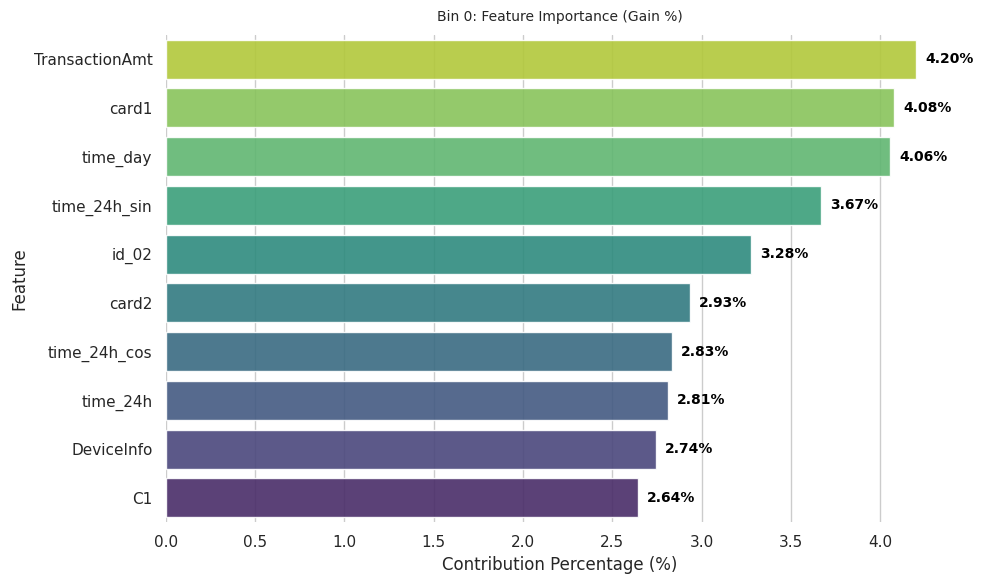

In [ ]:
# 3-1　モデル評価　セグメント別TSCV　ビン0(20＄以下)

def plot_importance_pct(model, features, target_bin_val):
    """
    学習済みモデルから寄与率(%)を算出し、指定のグラデーションでグラフ化する
    """
    # 重要度の計算
    importance = model.feature_importances_
    df_importance = pd.DataFrame({'feature': features, 'importance': importance})

    # 全体の合計 Gain を 100% とした時の比率を計算
    df_importance['percentage'] = (df_importance['importance'] / df_importance['importance'].sum()) * 100

    # 上位10位を抽出
    df_top10 = df_importance.sort_values('percentage', ascending=False).head(10)

    # グラフのスタイル設定（フォント指定なしで汎用性確保）
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(10, 6))

    # 棒グラフ（viridis_r: 低い=紫/青、高い=黄）
    ax = sns.barplot(
        x='percentage',
        y='feature',
        data=df_top10,
        palette='viridis_r',
        edgecolor='white',
        alpha=0.9
    )

    # 棒の先端に％を表示
    for p in ax.patches:
        width = p.get_width()
        ax.text(
            width + 0.05,
            p.get_y() + p.get_height() / 2,
            f'{width:.2f}%',
            color='black', ha='left', va='center', fontsize=10, fontweight='bold'
        )

    # 装飾
    plt.title(f'Bin {target_bin_val}: Feature Importance (Gain %)', fontsize=10, pad=10)
    plt.xlabel('Contribution Percentage (%)', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    sns.despine(left=True, bottom=True)
    plt.tight_layout()
    plt.show()

plot_importance_pct(model, features, target_bin_val=0)

*   低額帯ではTransactionAmtが首位であるものの、寄与度は４％程度に留まった。様々な情報から分析しているため、ロバスト性の高い分析モデルと思料される。

*   デバイスインフォの寄与率は想定より低く、2.74％に留まった。また、24時間周期系の特徴量の寄与度が多く、低額帯では一定の時刻に不正が行われていると思料される。

In [ ]:
# 3-2　モデル実装　セグメント別TSCV　ビン1(20＄～68.8＄)

# --- 設定 ---
threshold = 0.8
train_b1 = train[train['Amt_turning'] == 1].copy()
features = [c for c in train.columns if c not in ['isFraud', 'TransactionID']]
test_months = [2, 3, 4, 5]

metrics_store = []

print(f"直近2ヶ月スライド型 検証開始（Threshold: {threshold}）...")

for val_m in test_months:
    # 直近2ヶ月（val_m-2 と val_m-1）を学習データとして抽出
    train_mask = (train_b1['time_month'] >= (val_m - 2)) & (train_b1['time_month'] < val_m)

    X_train = train_b1[train_mask][features]
    y_train = train_b1[train_mask]['isFraud']

    val_data = train_b1[train_b1['time_month'] == val_m]
    X_val = val_data[features]
    y_val = val_data['isFraud']
    amounts = val_data['TransactionAmt']

    if len(X_train) == 0 or len(X_val) == 0:
        continue

    ratio = (y_train == 0).sum() / (y_train == 1).sum()

    model = lgb.LGBMClassifier(n_estimators=300,
                               learning_rate=0.05,
                               scale_pos_weight=ratio,
                               random_state=42,
                               verbose=-1)

    model.fit(X_train, y_train, eval_metric='average_precision')

    probs = model.predict_proba(X_val)[:, 1]
    preds = (probs >= threshold).astype(int)

    # 指標計算
    auc_roc = roc_auc_score(y_val, probs)
    auc_pr = average_precision_score(y_val, probs)
    det_mask = (preds == 1) & (y_val == 1)
    mis_mask = (preds == 0) & (y_val == 1)

    metrics_store.append({
        'auc_roc': auc_roc, 'auc_pr': auc_pr,
        'weighted_recall': amounts[det_mask].sum() / amounts[y_val == 1].sum() if (y_val == 1).any() else 0,
        'avg_det_amt': amounts[det_mask].mean() if det_mask.any() else 0,
        'avg_mis_amt': amounts[mis_mask].mean() if mis_mask.any() else 0,
        'p1': precision_score(y_val, preds, pos_label=1, zero_division=0),
        'r1': recall_score(y_val, preds, pos_label=1, zero_division=0),
        'f1_1': f1_score(y_val, preds, pos_label=1, zero_division=0),
        'p0': precision_score(y_val, preds, pos_label=0),
        'r0': recall_score(y_val, preds, pos_label=0),
        'f1_0': f1_score(y_val, preds, pos_label=0)
    })

# --- 平均値の算出 ---
avg = pd.DataFrame(metrics_store).mean()

print("\n" + "="*75)
print(f" 直近2ヶ月スライド平均レポート (Threshold: {threshold})")
print("="*75)
print(f"平均検知額: ${avg.avg_det_amt:,.0f} | 平均見逃し額: ${avg.avg_mis_amt:,.0f}")
print(f"金額荷重Recall: {avg.weighted_recall:.4f} | PR-AUC: {avg.auc_pr:.4f} | ROC-AUC: {avg.auc_roc:.4f}")
print("-" * 75)
print(f"🟥 クラス1(不正) | Precision: {avg.p1:.4f} | Recall: {avg.r1:.4f} | F1: {avg.f1_1:.4f}")
print(f"🟩 クラス0(正常) | Precision: {avg.p0:.4f} | Recall: {avg.r0:.4f} | F1: {avg.f1_0:.4f}")
print("="*75)

model_b1 = model

直近2ヶ月スライド型 検証開始（Threshold: 0.8）...

 直近2ヶ月スライド平均レポート (Threshold: 0.8)
平均検知額: $40 | 平均見逃し額: $44
金額荷重Recall: 0.4082 | PR-AUC: 0.5684 | ROC-AUC: 0.8918
---------------------------------------------------------------------------
🟥 クラス1(不正) | Precision: 0.7526 | Recall: 0.4362 | F1: 0.5485
🟩 クラス0(正常) | Precision: 0.9827 | Recall: 0.9952 | F1: 0.9889


閾値0.7のほうがF1スコア(不正)は0.5567と高かったが、中低金額帯であること、全件のうち45％を占める割合であることを考慮し、プレシジョン(不正)75%を優先したところ閾値0.8となった。

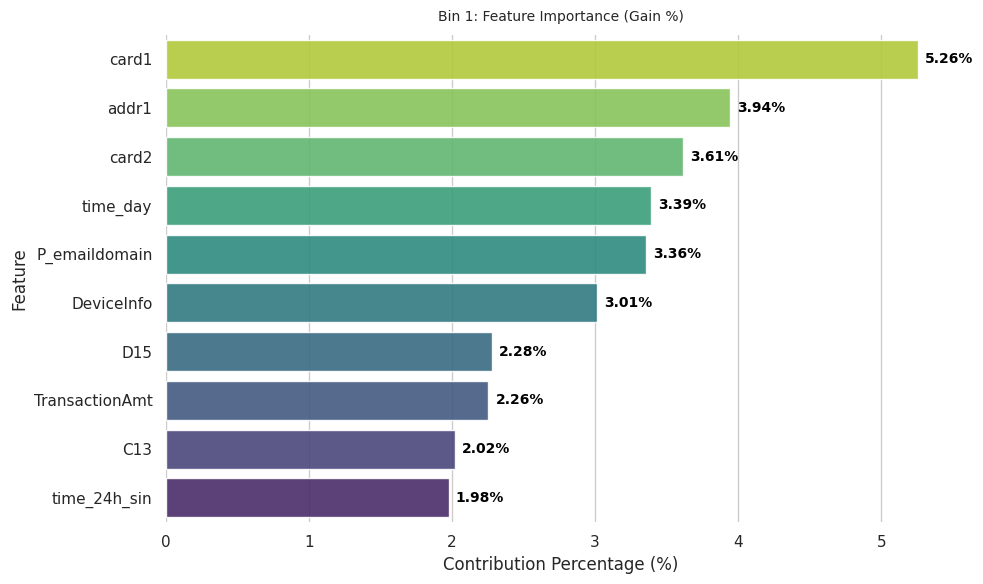

In [ ]:
# 3-2　モデル評価　セグメント別TSCV　ビン1(20＄～68.8＄)

plot_importance_pct(model, features, target_bin_val=1)

　低中金額帯では金額の寄与度がさがり、24時間周期系の指標がランク外に落ち、代わりにカード情報やアドレス、Pメールドメインなどがランクインした。  
　この金額帯では不正を行う時間帯を工夫するよりも、端末から発せられる情報自体を偽装する傾向にあると仮定できる。

In [ ]:
#リキャスト(金額infとなったため)
train['TransactionAmt'] = train['TransactionAmt'].astype('float32')

In [ ]:
# 3-3　モデル評価　セグメント別TSCV　ビン2(68.8＄～445＄)


# --- 設定 ---#
threshold = 0.8
train_b2 = train[train['Amt_turning'] == 2].copy()
features = [c for c in train.columns if c not in ['isFraud', 'TransactionID']]
test_months = [2, 3, 4, 5]

metrics_store = []

print(f"直近2ヶ月スライド型 検証開始（Threshold: {threshold}）...")

for val_m in test_months:
    # 直近2ヶ月（val_m-2 と val_m-1）を学習データとして抽出
    train_mask = (train_b2['time_month'] >= (val_m - 2)) & (train_b2['time_month'] < val_m)

    X_train = train_b2[train_mask][features]
    y_train = train_b2[train_mask]['isFraud']

    # --- 学習用データの金額から重みを計算 ---
    train_amounts = train_b2[train_mask]['TransactionAmt']
    median_amt_b3 = train_b2['TransactionAmt'].median()
    a = 2.0
    # 不正(1)なら(1+2.0)=3倍、かつ金額に比例した重み付け
    sw = (train_amounts / median_amt_b3) * (1 + (a * y_train))


    val_data = train_b2[train_b2['time_month'] == val_m]
    X_val = val_data[features]
    y_val = val_data['isFraud']
    amounts = val_data['TransactionAmt']

    if len(X_train) == 0 or len(X_val) == 0:
        continue

    ratio = (y_train == 0).sum() / (y_train == 1).sum()

    model = lgb.LGBMClassifier(n_estimators=300,
                               learning_rate=0.05,
                               scale_pos_weight=ratio,
                               random_state=42,
                               verbose=-1)

    model.fit(X_train, y_train, sample_weight=sw)

    probs = model.predict_proba(X_val)[:, 1]
    preds = (probs >= threshold).astype(int)

    # 指標計算
    auc_roc = roc_auc_score(y_val, probs)
    auc_pr = average_precision_score(y_val, probs)
    det_mask = (preds == 1) & (y_val == 1)
    mis_mask = (preds == 0) & (y_val == 1)

    metrics_store.append({
        'auc_roc': auc_roc, 'auc_pr': auc_pr,
        'weighted_recall': amounts[det_mask].sum() / amounts[y_val == 1].sum() if (y_val == 1).any() else 0,
        'avg_det_amt': amounts[det_mask].mean() if det_mask.any() else 0,
        'avg_mis_amt': amounts[mis_mask].mean() if mis_mask.any() else 0,
        'p1': precision_score(y_val, preds, pos_label=1, zero_division=0),
        'r1': recall_score(y_val, preds, pos_label=1, zero_division=0),
        'f1_1': f1_score(y_val, preds, pos_label=1, zero_division=0),
        'p0': precision_score(y_val, preds, pos_label=0),
        'r0': recall_score(y_val, preds, pos_label=0),
        'f1_0': f1_score(y_val, preds, pos_label=0)
    })

# --- 平均値の算出 ---
avg = pd.DataFrame(metrics_store).mean()

print("\n" + "="*75)
print(f" 直近2ヶ月スライド平均レポート (Threshold: {threshold})")
print("="*75)
print(f"平均検知額: ${avg.avg_det_amt:,.0f} | 平均見逃し額: ${avg.avg_mis_amt:,.0f}")
print(f"金額荷重Recall: {avg.weighted_recall:.4f} | PR-AUC: {avg.auc_pr:.4f} | ROC-AUC: {avg.auc_roc:.4f}")
print("-" * 75)
print(f"🟥 クラス1(不正) | Precision: {avg.p1:.4f} | Recall: {avg.r1:.4f} | F1: {avg.f1_1:.4f}")
print(f"🟩 クラス0(正常) | Precision: {avg.p0:.4f} | Recall: {avg.r0:.4f} | F1: {avg.f1_0:.4f}")
print("="*75)

model_b2 = model

直近2ヶ月スライド型 検証開始（Threshold: 0.8）...

 直近2ヶ月スライド平均レポート (Threshold: 0.8)
平均検知額: $165 | 平均見逃し額: $181
金額荷重Recall: 0.4237 | PR-AUC: 0.4590 | ROC-AUC: 0.8669
---------------------------------------------------------------------------
🟥 クラス1(不正) | Precision: 0.4140 | Recall: 0.4472 | F1: 0.4287
🟩 クラス0(正常) | Precision: 0.9788 | Recall: 0.9762 | F1: 0.9775


　高中金額帯から精度が落ち込み始めたため、金額重み付けを実施。多少改善されたものの不正のF1スコアは低くなった。

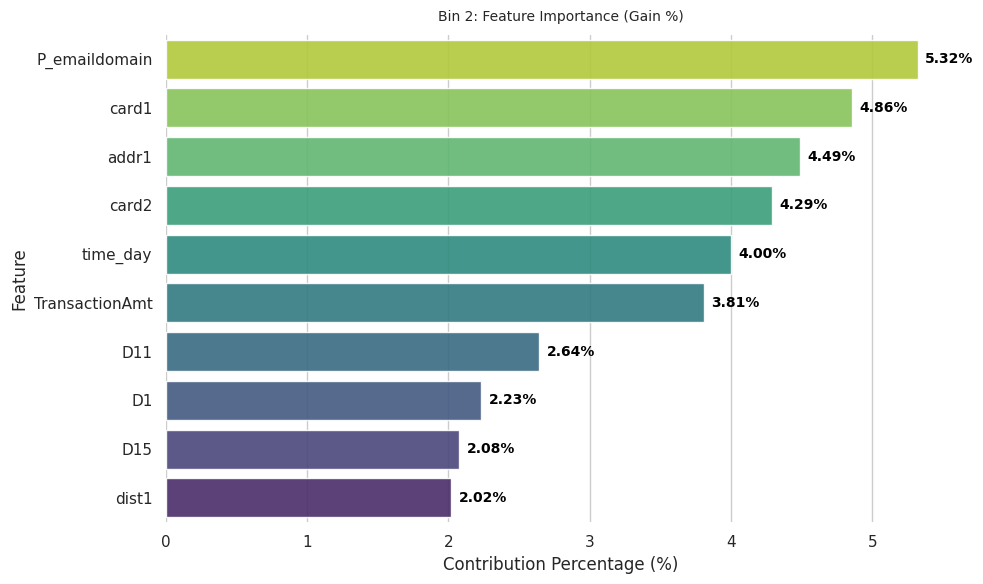

In [ ]:
# 3-3　モデル評価　セグメント別TSCV　ビン2(68.8＄～445＄)

plot_importance_pct(model, features, target_bin_val=2)

　Pメールドメインの寄与度が一位であり、以降はカード情報等の寄与度が高かった。一方で端末から発する情報は低中金額帯より少なく、代わりにD系の特徴量が増えている。

In [ ]:
# 3-4　モデル実装　セグメント別TSCV　ビン3(445＄～)

# --- 設定 ---
threshold = 0.05
train_b3 = train[train['Amt_turning'] == 3].copy()
features = [c for c in train.columns if c not in ['isFraud', 'TransactionID']]
test_months = [2, 3, 4, 5]

metrics_store = []

print(f"直近2ヶ月スライド型 検証開始（Threshold: {threshold}）...")

for val_m in test_months:
    # --- データ抽出 ---
    train_mask = (train_b3['time_month'] >= (val_m - 2)) & (train_b3['time_month'] < val_m)
    X_train = train_b3[train_mask][features]
    y_train = train_b3[train_mask]['isFraud']

    # --- 学習用データの金額から重みを計算 ---
    train_amounts = train_b3[train_mask]['TransactionAmt']
    median_amt_b3 = train_b3['TransactionAmt'].median()
    a = 10.0
    # 不正(1)なら(1+2.0)=3倍、かつ金額に比例した重み付け
    sw = (train_amounts / median_amt_b3) * (1 + (a * y_train))

    # --- 検証データの準備 ---
    val_data = train_b3[train_b3['time_month'] == val_m]
    X_val = val_data[features]
    y_val = val_data['isFraud']
    amounts = val_data['TransactionAmt']

    if len(X_train) == 0 or len(X_val) == 0:
        continue

    # --- モデル学習 ---
    ratio = (y_train == 0).sum() / (y_train == 1).sum()

    model = lgb.LGBMClassifier(n_estimators=300,
                               learning_rate=0.05,
                               scale_pos_weight=ratio,
                               random_state=42,
                               verbose=-1)

    # 重み (sample_weight) を渡してフィット
    model.fit(X_train, y_train, sample_weight=sw)

    # --- 予測処理 (ここを追加) ---
    probs = model.predict_proba(X_val)[:, 1]
    preds = (probs >= threshold).astype(int)

    # --- 指標計算 ---
    auc_roc = roc_auc_score(y_val, probs)
    auc_pr = average_precision_score(y_val, probs)
    det_mask = (preds == 1) & (y_val == 1)
    mis_mask = (preds == 0) & (y_val == 1)

    metrics_store.append({
        'auc_roc': auc_roc, 'auc_pr': auc_pr,
        'weighted_recall': amounts[det_mask].sum() / amounts[y_val == 1].sum() if (y_val == 1).any() else 0,
        'avg_det_amt': amounts[det_mask].mean() if det_mask.any() else 0,
        'avg_mis_amt': amounts[mis_mask].mean() if mis_mask.any() else 0,
        'p1': precision_score(y_val, preds, pos_label=1, zero_division=0),
        'r1': recall_score(y_val, preds, pos_label=1, zero_division=0),
        'f1_1': f1_score(y_val, preds, pos_label=1, zero_division=0),
        'p0': precision_score(y_val, preds, pos_label=0),
        'r0': recall_score(y_val, preds, pos_label=0),
        'f1_0': f1_score(y_val, preds, pos_label=0)
    })

# --- 平均値の算出 ---
avg = pd.DataFrame(metrics_store).mean()

print("\n" + "="*75)
print(f" 直近2ヶ月スライド平均レポート (Threshold: {threshold})")
print("="*75)
print(f"平均検知額: ${avg.avg_det_amt:,.0f} | 平均見逃し額: ${avg.avg_mis_amt:,.0f}")
print(f"金額荷重Recall: {avg.weighted_recall:.4f} | PR-AUC: {avg.auc_pr:.4f} | ROC-AUC: {avg.auc_roc:.4f}")
print("-" * 75)
print(f"🟥 クラス1(不正) | Precision: {avg.p1:.4f} | Recall: {avg.r1:.4f} | F1: {avg.f1_1:.4f}")
print(f"🟩 クラス0(正常) | Precision: {avg.p0:.4f} | Recall: {avg.r0:.4f} | F1: {avg.f1_0:.4f}")
print("="*75)

model_b3 = model

直近2ヶ月スライド型 検証開始（Threshold: 0.05）...

 直近2ヶ月スライド平均レポート (Threshold: 0.05)
平均検知額: $795 | 平均見逃し額: $926
金額荷重Recall: 0.6649 | PR-AUC: 0.4909 | ROC-AUC: 0.8594
---------------------------------------------------------------------------
🟥 クラス1(不正) | Precision: 0.2457 | Recall: 0.6973 | F1: 0.3594
🟩 クラス0(正常) | Precision: 0.9787 | Recall: 0.8675 | F1: 0.9197


プレシジョン値は低くなったが、高額帯の被害総額や件数の少なさから金額荷重リコールを優先し、閾値は0.05とした。

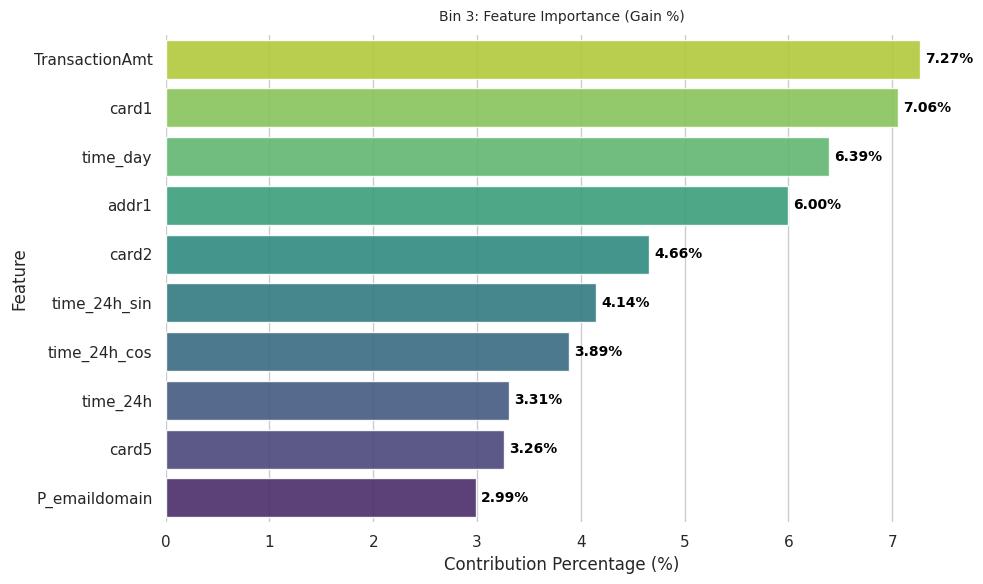

In [ ]:
# 3-4　モデル評価　セグメント別TSCV　ビン3(445＄～)

plot_importance_pct(model, features, target_bin_val=3)

高額帯において、24時間周期や金額が再度高くなり、低額帯と類似している。低額帯の不正は高額帯の不正の試験的に行われている可能性を示唆しているが、検知率は高額帯のほうが低額帯より低い。ただ、高額帯の検知率の低さに関しては不正サンプル数の少なさによる学習不足に起因する部分もあるため、仮定の域を超えない。

In [ ]:
#4-1  モデル実装　全データ再学習

# 全データで最終モデルを再学習
features = [c for c in train.columns if c not in ['isFraud', 'TransactionID']]

# Bin0
tb0 = train[train['Amt_turning'] == 0]
ratio0 = (tb0['isFraud']==0).sum() / (tb0['isFraud']==1).sum()
model_b0 = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, scale_pos_weight=ratio0, random_state=42, verbose=-1)
model_b0.fit(tb0[features], tb0['isFraud'])

# Bin1
tb1 = train[train['Amt_turning'] == 1]
ratio1 = (tb1['isFraud']==0).sum() / (tb1['isFraud']==1).sum()
model_b1 = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, scale_pos_weight=ratio1, random_state=42, verbose=-1)
model_b1.fit(tb1[features], tb1['isFraud'])

# Bin2
tb2 = train[train['Amt_turning'] == 2]
median_amt = tb2['TransactionAmt'].median()
sw3 = (tb2['TransactionAmt'] / median_amt) * (1 + 2.0 * tb2['isFraud'])
ratio2 = (tb2['isFraud']==0).sum() / (tb2['isFraud']==1).sum()
model_b2 = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, scale_pos_weight=ratio2, random_state=42, verbose=-1)
model_b2.fit(tb2[features], tb2['isFraud'])

# Bin3（金額重み付き）
tb3 = train[train['Amt_turning'] == 3]
median_amt = tb3['TransactionAmt'].median()
sw3 = (tb3['TransactionAmt'] / median_amt) * (1 + 10.0 * tb3['isFraud'])
ratio3 = (tb3['isFraud']==0).sum() / (tb3['isFraud']==1).sum()
model_b3 = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, scale_pos_weight=ratio3, random_state=42, verbose=-1)
model_b3.fit(tb3[features], tb3['isFraud'], sample_weight=sw3)

print("全データ再学習完了")

全データ再学習完了


In [ ]:
#4-2 テストデータ適用

# 各Binのモデルをそれぞれ学習して確率値を結合する

# 先に各Binのモデルを変数に保存しておく必要があります
# セル11の末尾に → model_b0 = model
# セル15の末尾に → model_b1 = model
# セル18の末尾に → model_b2 = model
# セル21の末尾に → model_b3 = model

test_probs = model.predict_proba(test[features])[:, 1]
test['prob'] = test_probs

# --- 確率値の結合 ---
test['prob'] = 0.0  # 初期化

# Bin0
mask0 = test['Amt_turning'] == 0
test.loc[mask0, 'prob'] = model_b0.predict_proba(test[mask0][features])[:, 1]

# Bin1
mask1 = test['Amt_turning'] == 1
test.loc[mask1, 'prob'] = model_b1.predict_proba(test[mask1][features])[:, 1]

# Bin2
mask2 = test['Amt_turning'] == 2
test.loc[mask2, 'prob'] = model_b2.predict_proba(test[mask2][features])[:, 1]

# Bin3
mask3 = test['Amt_turning'] == 3
test.loc[mask3, 'prob'] = model_b3.predict_proba(test[mask3][features])[:, 1]

submission = test[['TransactionID', 'prob']].copy()
submission.columns = ['TransactionID', 'isFraud']
submission.to_csv('submission.csv', index=False)
print("完了")

完了


Private Score 0.875
Public Score 0.910


【モデル選定のプロセスと考察】  
　当初、ビジネス上の損失を最小化するため、金額帯別に4つのセグメント（Bin0〜3）に分割したモデルを構築した。しかし、ベースラインとして作成した「全データ統合の単一モデル」と比較した結果、単一モデルの方がKaggleのスコアで上回る結果となった。  
  
【結論】  
　セグメント別において、金額帯で分割し、なおかつ２カ月スライドウィンドウを適用したことで各Binのサンプルサイズが減少し、局所的な過学習を起こした可能性が高い。そのため、単一モデルの方が全金額帯に共通する不正のサインに学習できていた。  
　ただし、以下の事項より、金額セグメント別に運用することについてはメリットがあると感じた。
*   プライベートスコアで0.9％程度の差であること。
*   金額帯別の不正手段の動向を探れること。
*   金額帯別にリコール優先かプレシジョン優先かを選択できるため、件数自体が少なく、かつ被害金額が大きい高金額帯においてはリコール優先し、件数の多い低金額帯ではプレシジョン優先にすることで監視コストを抑えつつ費用帯効果の向上を見込めること。  

　一方で、モデル構築においては複雑であり、適切な分割ラインの策定など、運用・保守の面では単一モデルの方が優れている。


総評

　局所的にセグメント化した低金額層はそこそこの精度となったが、その他の層においてはいまいちな結果となった。セグメント化自体は低層から中層以降へのモデル寄与度の遷移から正しい戦略であったといえる。そのため、精度がでなかった原因としてはセグメントの線の引き方や特徴量の追加不足が如実に表れた結果であったと思料される。  
特にcard1についてはどのセグメントでも寄与度が高かったため、単体での検討は当然のこと、組み合わせを含めた特徴量の検討を行うべきであった。この点については当該PJの進行・構成自体が悪く、最初の時点で重要度の高い指標である金額及び時間軸について特徴量を追加していればＥＤＡ時点でのモデル試走で着眼できたはずである。  
　また、現時点ではあまりに自身の技術や知見が不足しすぎており、膨大なデータ量に振り回されることが多かった。その結果、効率的な分析ができず、時間不足に陥り、特徴量の不足に至った。また、初月の不正率の低さから２カ月スライドウィンドウを選択した発想自体は悪くなかったと感じているが、セグメントで分割した状態を考えれば、不均衡データで過剰な分割を行っていることは気づいてしかるべき事項であった。  
この点について、スタティファイドCVを選択すれば、フォールド別で比率を安定させるため改善されるが、時間をシャッフルするので「未来のデータで過去を予測する」という情報リークが発生する。結局のところ、セグメント別とTSCVの併用モデルでは過剰分割による学習不足に陥る課題は残る。  
　コンペへの取り組みは当該PJで一旦の区切りとして、今後は基礎的な学習の振り返りや、他者のコード等を参考に、自身の足りてなかったところをより深く明確にしていき、改善案または代替案を模索していきたい。